# SUPERVISED SOLVERS FOR THE 8-PUZZLE

This notebook reads the `8_puzzle_asts.csv` dataset and trains three supervised models:

1. Decision tree regularized by `ccp_alpha`;
2. Logistic regression;
3. KNN classifier.

Finally, these models are incorporated into hybrid solvers, which first query a memory of known states and, when the current state is not stored in memory, infer the next move using the classifier.

## SETTINGS

In [1]:
import warnings


warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
import sys

import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt

from pathlib         import Path
from IPython.display import display
from time            import perf_counter

from sklearn.pipeline      import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose       import ColumnTransformer

from sklearn.model_selection import GridSearchCV          , StratifiedKFold, train_test_split
from sklearn.metrics         import ConfusionMatrixDisplay, accuracy_score , classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors    import KNeighborsClassifier
from sklearn.tree         import DecisionTreeClassifier, plot_tree

In [3]:
N = 3

RANDOM_STATE = 42

## DATA LOADING

The expected main paths for the dataset is `data/8_puzzle_asts.csv` or `notebooks/data/8_puzzle_asts.csv`, the code below checks both locations.

In [4]:
def find_project_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()

    for path in (start, *start.parents):
        if (path / 'puzzle').is_dir():
            return path

    raise RuntimeError('Unable to locate the project root.')


PROJECT_ROOT    = find_project_root()
DATA_CANDIDATES = [
    PROJECT_ROOT /               'data' / '8_puzzle_asts.csv',
    PROJECT_ROOT / 'notebooks' / 'data' / '8_puzzle_asts.csv',
]

DATA_PATH = next(
    (
        path
        for path in DATA_CANDIDATES
        if  path.exists()
    ),
    None
)

if DATA_PATH is None:
    searched = '\n'.join(
        f'- {path}'
        for path in DATA_CANDIDATES
    )

    raise FileNotFoundError(
        'File 8_puzzle_asts.csv was not found. Searched paths:\n' + searched
    )


print(f'Project: {PROJECT_ROOT}')
print(f'Dataset: {   DATA_PATH}')

Project: /home/rei-luisinho/solving_8_puzzle
Dataset: /home/rei-luisinho/solving_8_puzzle/notebooks/data/8_puzzle_asts.csv


Load the puzzle and solver components:

In [5]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


from puzzle.search_algorithm import ASTS
from puzzle                  import formulations

pygame 2.5.2 (SDL 2.28.2, Python 3.12.3)
Hello from the pygame community. https://www.pygame.org/contribute.html


Loading the dataset and removing duplicate rows:

In [6]:
df = pd.read_csv(DATA_PATH)

rows_before = df.shape[0]
columns     = df.shape[1]

df = df.drop_duplicates()

rows_after   = df.shape[0]
removed_rows = rows_before - rows_after

print(f'Columns = {columns:,}')
print(f'Rows before removing duplicates = { rows_before:,}')
print(f'Rows after  removing duplicates = {  rows_after:,}')
print(f'Duplicate rows removed          = {removed_rows:,}')

Columns = 13
Rows before removing duplicates = 149,386
Rows after  removing duplicates = 22,575
Duplicate rows removed          = 126,811


In [7]:
display(df.head(5))

,position0,position1,position2,position3,position4,position5,position6,position7,position8,move_up,move_right,move_down,move_left
0,4,8,2,1,0,7,3,6,5,0,0,1,0
1,4,0,2,1,8,7,3,6,5,0,1,0,0
2,0,4,2,1,8,7,3,6,5,1,0,0,0
3,1,4,2,0,8,7,3,6,5,1,0,0,0
4,1,4,2,3,8,7,0,6,5,0,0,0,1


In [8]:
POSITION_COLUMNS = [
    'position' + str(idx)
    for idx in range(N**2)
]
MOVE_COLUMNS = ['move_up'   ,
                'move_right',
                'move_down' ,
                'move_left' ]

LABEL_TO_ACTION = {
    'move_up'    : 'u',
    'move_right' : 'r',
    'move_down'  : 'd',
    'move_left'  : 'l',
}
ACTION_TO_LABEL = {
    action : label
    for label, action in LABEL_TO_ACTION.items()
}
ACTION_NAMES = {
    'u' : 'up'   ,
    'r' : 'right',
    'd' : 'down' ,
    'l' : 'left' ,
}

missing_columns = [
    column
    for column in POSITION_COLUMNS + MOVE_COLUMNS
    if  column not in df.columns
]

if missing_columns:
    raise ValueError(f'Missing columns in the dataset: {missing_columns}')

one_hot_sum = df[MOVE_COLUMNS].sum(axis=1)
if not one_hot_sum.eq(1).all():
    invalid_rows = int((~one_hot_sum.eq(1)).sum())

    raise ValueError(f'There are {invalid_rows} rows without exactly one active one-hot label.')

for column in POSITION_COLUMNS + MOVE_COLUMNS:
    df[column] = df[column].astype(int)

df['label' ] = df[MOVE_COLUMNS].idxmax(axis=1)
df['action'] = df['label'     ].map   (LABEL_TO_ACTION)

display(df[POSITION_COLUMNS + ['label', 'action']].head())

,position0,position1,position2,position3,position4,position5,position6,position7,position8,label,action
0,4,8,2,1,0,7,3,6,5,move_down,d
1,4,0,2,1,8,7,3,6,5,move_right,r
2,0,4,2,1,8,7,3,6,5,move_up,u
3,1,4,2,0,8,7,3,6,5,move_up,u
4,1,4,2,3,8,7,0,6,5,move_left,l


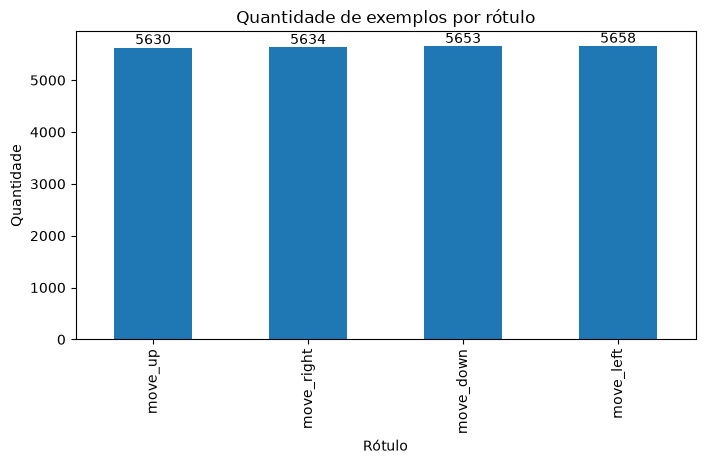

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

label_counts = df['label'].value_counts().reindex(MOVE_COLUMNS, fill_value=0)
label_counts.plot(kind='bar', ax=ax)

ax.set_title ('Quantidade de exemplos por rótulo')
ax.set_xlabel('Rótulo'    )
ax.set_ylabel('Quantidade')
ax.bar_label (ax.containers[0], fmt='%.0f')

plt.show()

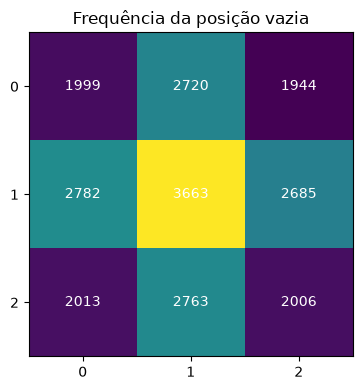

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))

blank_counts = (
    df[POSITION_COLUMNS] == 0
).sum().to_numpy().reshape(N, N)

ax.imshow(blank_counts, cmap='viridis')

ax.set_title ('Frequência da posição vazia')
ax.set_xticks(range(N))
ax.set_yticks(range(N))

for row in range(N):
    for col in range(N):
        ax.text(col, row, int(blank_counts[row, col]), ha='center', va='center', color='white')

plt.tight_layout()
plt.show()

## TRAIN TEST SPLIT

In [11]:
X = df[POSITION_COLUMNS]
y = df['action'        ]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size   =0.1,
    stratify    =y  ,
    random_state=RANDOM_STATE,
)

print(f'Train = {X_train.shape[0]:,} rows')
print(f'Test  = {X_test .shape[0]:,} rows')

Train = 20,317 rows
Test  = 2,258 rows


In [12]:
display(pd.DataFrame({
    'train' : y_train.value_counts().sort_index(),
    'test'  : y_test .value_counts().sort_index(),
}).fillna(0).astype(int))

,train,test
action,,
d,5088,565
l,5092,566
r,5070,564
u,5067,563


## DECISION TREE

The decision tree is trained in two steps: first, the cost-complexity pruning path (`cost_complexity_pruning_path`) is computed; then, a reduced grid of `ccp_alpha` values is evaluated using stratified cross-validation.

In [13]:
base_tree = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    class_weight='balanced'  ,
)

path = base_tree.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = np.unique(path.ccp_alphas)
ccp_alphas = ccp_alphas[np.isfinite(ccp_alphas)]
ccp_alphas = ccp_alphas[ccp_alphas >= 0        ]

if len(ccp_alphas) > 35:
    ccp_grid = np.unique(np.quantile(ccp_alphas, np.linspace(0, 1, 35)))
else:
    ccp_grid = ccp_alphas

if len(ccp_grid) == 0:
    ccp_grid = np.array([0.0])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

tree_search = GridSearchCV(
    estimator         =base_tree ,
    scoring           ='accuracy',
    cv                =cv  ,
    n_jobs            =-1  ,
    return_train_score=True,
    param_grid={
        'ccp_alpha' : ccp_grid
    },
)

tree_search.fit(X_train, y_train)
tree_model = tree_search.best_estimator_

print(f'Best CV accuracy = {tree_search.best_score_:.4f}')

Best CV accuracy = 0.7309


## LOGISTIC REGRESSION

The board positions are treated as categorical variables: each column indicates which tile occupies a given cell. For this reason, the logistic regression model applies one-hot encoding before the classification step.

In [14]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse       =True)


logreg_preprocessor = ColumnTransformer(
    transformers=[
        (
            'tile_at_position'    ,
            make_one_hot_encoder(),
            POSITION_COLUMNS      ,
        ),
    ],
    remainder='drop',
)

In [15]:
logreg_model = Pipeline(steps=[
    ('one_hot', logreg_preprocessor),
    ('model'  , LogisticRegression(
        penalty     ='l2'   ,
        max_iter    =1000   ,
        solver      ='lbfgs',
        n_jobs      =-1     ,
        class_weight='balanced'  ,
        random_state=RANDOM_STATE,
    )),
])

logreg_model.fit(X_train, y_train)

y_pred        = logreg_model.predict(X_test)
test_accuracy = accuracy_score      (y_test, y_pred)

print(f'Test accuracy = {test_accuracy * 100:.2f}%')

Test accuracy = 49.34%


## KNN

KNN uses the same one-hot encoding of the board positions to compare boards as categorical configurations. The model weights neighbors by their Euclidean distance in this representation, assigning greater influence to known examples that are more similar to the current state.

In [16]:
knn_model = Pipeline(steps=[
    ('one_hot', logreg_preprocessor),
    ('model'  , KNeighborsClassifier(
        n_neighbors=7,
        weights    ='distance' ,
        metric     ='euclidean',
    )),
])

knn_model.fit(X_train, y_train)

y_pred        = knn_model.predict(X_test)
test_accuracy = accuracy_score   (y_test, y_pred)

print(f'Test accuracy = {test_accuracy * 100:.2f}%')

Test accuracy = 49.69%


## MODEL EVALUATION

In [17]:
models = [
    ('Decision Tree CCP'  , tree_model  ),
    ('KNN'                , knn_model   ),
    ('Logistic Regression', logreg_model),
]

test_predictions = {}
test_accuracies  = {}

for name, model in models:
    y_pred = model.predict(X_test)

    test_predictions[name] = y_pred
    test_accuracies [name] = accuracy_score(y_test, y_pred)

for name, accuracy in test_accuracies.items():
    print(f'{name} - test accuracy = {accuracy:.4f}')

Decision Tree CCP - test accuracy = 0.7352
KNN - test accuracy = 0.4969
Logistic Regression - test accuracy = 0.4934


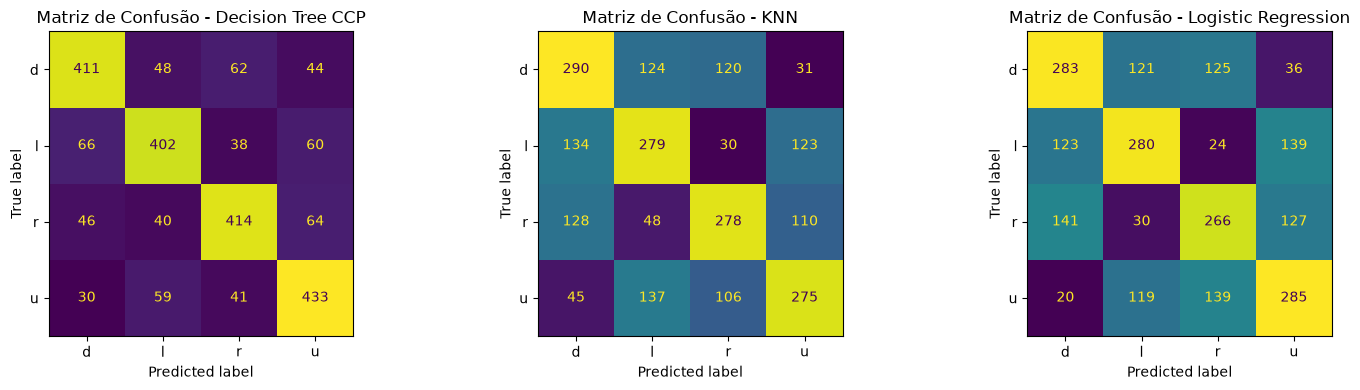

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, _) in zip(axes, models):
    ConfusionMatrixDisplay.from_predictions(
        y_test                ,
        test_predictions[name],
        ax      =ax   ,
        colorbar=False,
    )

    ax.set_title(f'Matriz de Confusão - {name}')

plt.tight_layout()
plt.show()

## TREE INTERPRETATION

The plot shows only the first levels of the tree to preserve readability. The feature importance table helps identify which board positions had the greatest influence on the model’s decisions.

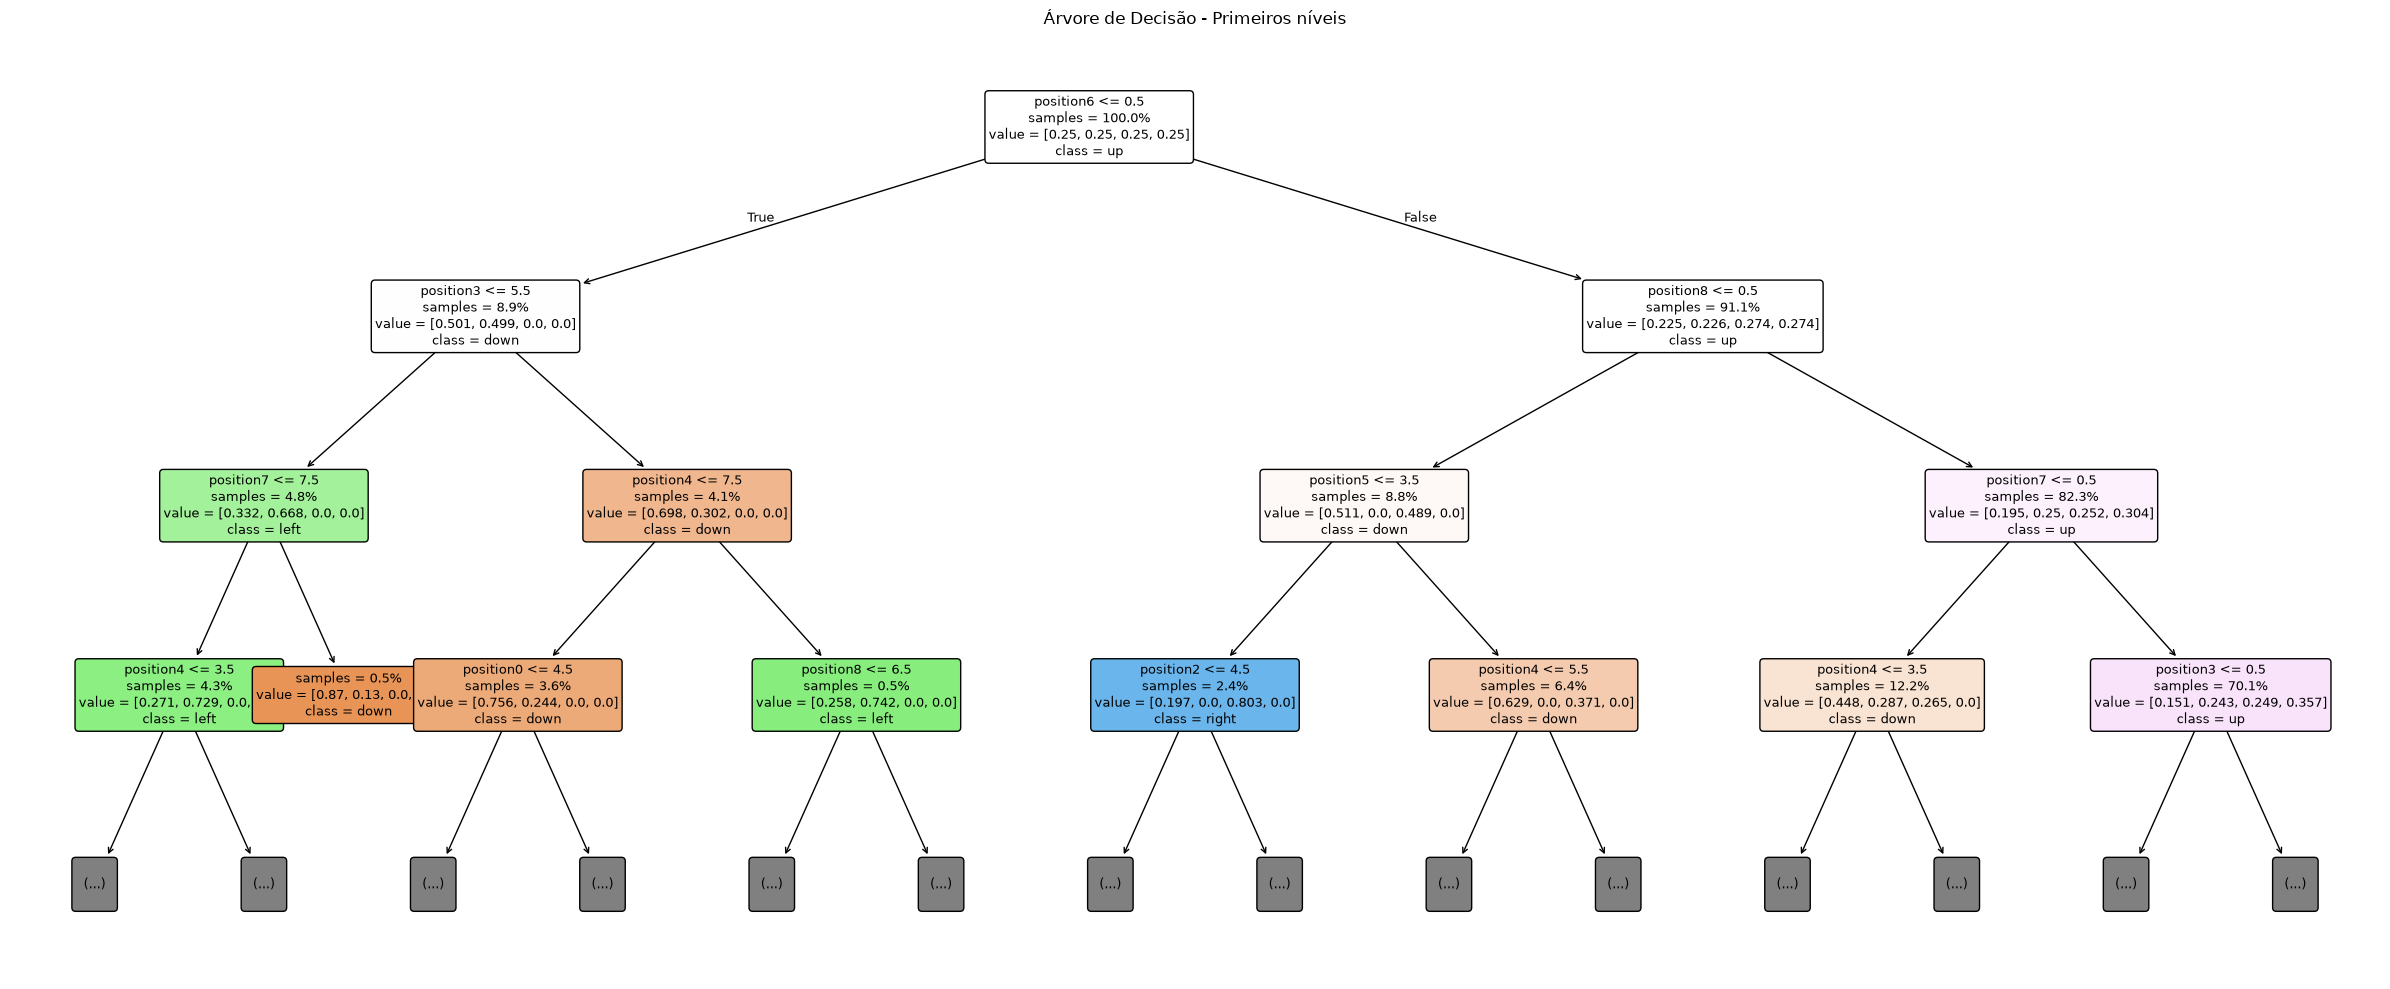

In [19]:
fig, ax = plt.subplots(figsize=(24, 10))

plot_tree(
    tree_model,

    feature_names=POSITION_COLUMNS,
    class_names  =[
        ACTION_NAMES[action]
        for action in tree_model.classes_
    ],

    filled    =True ,
    rounded   =True ,
    impurity  =False,
    proportion=True ,

    max_depth=3,
    fontsize =9,

    ax=ax,
)

ax.set_title('Árvore de Decisão - Primeiros níveis')

plt.tight_layout()
plt.show()

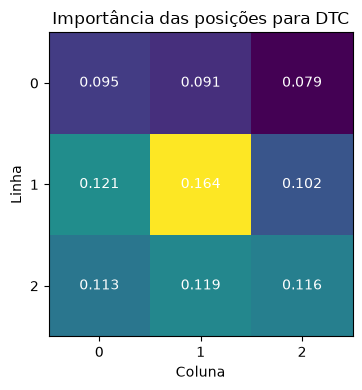

In [20]:
tree_importances = (
    pd.DataFrame({
        'feature'    : POSITION_COLUMNS               ,
        'importance' : tree_model.feature_importances_,
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

importance_grid = (
    tree_importances
    .set_index('feature')
    .reindex  (POSITION_COLUMNS)['importance']
    .to_numpy()
    .reshape (N, N)
)

fig, ax = plt.subplots(figsize=(5, 4))

ax.imshow(importance_grid, cmap='viridis')

ax.set_title ('Importância das posições para DTC')
ax.set_xticks(range(N))
ax.set_yticks(range(N))
ax.set_xlabel('Coluna')
ax.set_ylabel('Linha' )

for i in range(N):
    for j in range(N):
        ax.text(j, i, f'{importance_grid[i, j]:.3f}', ha='center', va='center', color='white')

plt.tight_layout()
plt.show()

## HYBRID SOLVER: MEMORY + INFERENCE

The solver below first queries an exact memory of known states, built from the training data. If the current state is found in memory, it reuses the stored action. Otherwise, it estimates probabilities with the classifier, filters the legal moves according to the current board, and, whenever possible, selects the legal move with the highest probability that does not return to an already visited state. At each step, it records the previous state, the resulting state, the decision source, the estimated probabilities, and the justification for the selected move.

In [21]:
INV_ACTIONS = {
    'l' : 'r',
    'r' : 'l',
    'u' : 'd',
    'd' : 'u',
}

ACTION_ORDER  = ['u', 'r', 'd', 'l']
PROBA_COLUMNS = [f'prob_{action}' for action in ACTION_ORDER]


def objective_grid():
    return formulations.objective_grid(N)


def state_key(grid):
    return tuple(np.asarray(grid).reshape(-1).astype(int).tolist())


def grid_to_features(grid):
    values = np.asarray(grid).reshape(-1).astype(int).tolist()

    return pd.DataFrame([values], columns=POSITION_COLUMNS)


def format_grid(grid):
    grid = np.asarray(grid).reshape(N, N)

    return '\n'.join(
        ' '.join(
            f'{value:>2}' for value in row
        )
        for row in grid
    )


def model_classes(model):
    if hasattr(model, 'classes_'):
        return model.classes_

    return model.named_steps['model'].classes_


def predict_action_scores(model, grid):
    features = grid_to_features(grid )
    classes  = model_classes   (model)

    if hasattr(model, 'predict_proba'):
        probabilities = model.predict_proba(features)[0]
        scores        = dict(zip(classes, probabilities))
    else:
        prediction = model.predict(features)[0]

        scores = {
            action : 0.0
            for action in classes
        }
        scores[prediction] = 1.0

    return {
        action : float(scores.get(action, 0.0))
        for action in ACTION_ORDER
    }


def build_movement_memory(features, labels):
    memory_source = features.copy()

    memory_source['action'] = pd.Series(
        labels, index=features.index
    ).astype(str)

    memory_rows = []
    for key_values, group in memory_source.groupby(POSITION_COLUMNS, sort=False):
        action_counts = group['action'].value_counts()
        max_count     = action_counts  .max()

        tied_actions    = set (action_counts[action_counts == max_count].index            )
        selected_action = next(action for action in ACTION_ORDER if action in tied_actions)

        memory_rows.append({
            'state'     : tuple(int(value) for value in key_values),
            'action'    : selected_action                          ,

            'examples'  : int  (action_counts.sum()            ),
            'agreement' : float(max_count / action_counts.sum()),
            'conflict'  : bool (len(action_counts) > 1),
        })

    memory = {
        row['state'] : row
        for row in memory_rows
    }

    return memory, pd.DataFrame(memory_rows)


movement_memory, movement_memory_audit = build_movement_memory(X_train, y_train)

print(f'Memorized states: {len(movement_memory):,}')
print(
    f'States with conflicts resolved by majority vote: '
    f'{int(movement_memory_audit["conflict"].sum()):,}'
)

Memorized states: 20,102
States with conflicts resolved by majority vote: 213


In [22]:
def choose_legal_action(grid, scores, visited, previous_action=None):
    available      = formulations.available_moves(grid)
    reverse_action = INV_ACTIONS .get (previous_action)

    ranked_actions   = sorted(ACTION_ORDER, key=scores.get, reverse=True)
    predicted_action = ranked_actions[0]

    legal_ranked = [
        action
        for action in ranked_actions
        if  action in available
    ]

    candidates = []
    for action in legal_ranked:
        next_grid = formulations.move_grid(grid, action)

        candidates.append({
            'action'      : action        ,
            'probability' : scores[action],
            'revisited'   : state_key(next_grid) in visited,
            'is_reverse'  : action == reverse_action       ,
        })

    if not candidates:
        return None, predicted_action, available, 'Sem movimento legal'

    preferred = [
        item
        for item in candidates
        if  not item['revisited'] and not item['is_reverse']
    ]

    if preferred:
        selected = preferred[0]
        reason   = 'Maior probabilidade legal sem revisitar estado'
    else:
        preferred = [
            item
            for item in candidates
            if  not item['revisited']
        ]

        if preferred:
            selected = preferred[0]
            reason   = 'Maior probabilidade legal sem revisitar estado'
        else:
            selected = candidates[0]
            reason   = 'Todos os movimentos legais revisitam estado; usando maior probabilidade legal'

    if selected['action'] != predicted_action:
        reason += '; predicao bruta era ilegal ou menos segura'

    return selected['action'], predicted_action, available, reason


def choose_memory_action(grid, memory, visited, previous_action=None):
    memory_row = memory.get(state_key(grid))

    if memory_row is None:
        return None, None, 'Estado não encontrado na memória'

    action    = memory_row['action']
    available = formulations.available_moves(grid)
    if action not in available:
        return None, action, 'Ação memorizada ilegal para o estado atual'

    next_grid = formulations.move_grid(grid, action)
    if state_key(next_grid) in visited:
        return None, action, 'Ação memorizada revisitaria estado; usando inferência'

    if previous_action is not None and action == INV_ACTIONS.get(previous_action):
        return None, action, 'Ação memorizada desfaria o movimento anterior; usando inferência'

    reason = (
        f'Ação encontrada na memoria (exemplos={memory_row["examples"]}, concordancia={memory_row["agreement"]:.2f})'
    )

    return action, action, reason


def run_policy_solver(model, start_grid, model_name, max_steps=80, memory=None):
    grid = np.array(start_grid, dtype=np.int8).reshape(N, N)

    previous_action = None
    visited         = {
        state_key(grid)
    }
    audit_rows      = []

    for step in range(max_steps):
        if formulations.won(grid):
            break

        memory_action, memory_prediction, memory_reason = choose_memory_action(
            grid           =grid        ,
            memory         =memory or {},
            visited        =visited        ,
            previous_action=previous_action,
        )

        if memory_action is not None:
            scores = {
                action : np.nan
                for action in ACTION_ORDER
            }

            chosen_action    = memory_action
            predicted_action = memory_prediction
            available        = formulations.available_moves(grid)

            reason          = memory_reason
            decision_source = 'memoria'
        else:
            scores = predict_action_scores(model, grid)

            chosen_action, predicted_action, available, reason = choose_legal_action(
                grid           =grid  ,
                scores         =scores,
                visited        =visited        ,
                previous_action=previous_action,
            )

            reason          = f'{memory_reason}; {reason}'
            decision_source = 'inferencia'

        if chosen_action is None:
            audit_rows.append({
                'step'             : step,
                'decision_source'  : decision_source ,
                'predicted_action' : predicted_action,

                'chosen_action' : None               ,
                'valid_moves'   : ','.join(available),

                'reason'       : reason,
                'state_before' : format_grid(grid),
                'state_after'  : None             ,

                **{
                    f'prob_{action}' : scores[action]
                    for action in ACTION_ORDER
                },
            })

            break

        next_grid = formulations.move_grid(grid, chosen_action)

        audit_rows.append({
            'step'             : step + 1        ,
            'decision_source'  : decision_source ,
            'predicted_action' : predicted_action,
            'chosen_action'    : chosen_action   ,

            'valid_moves' : ','.join(available),

            'reason'       : reason,
            'state_before' : format_grid(grid     ),
            'state_after'  : format_grid(next_grid),

            **{
                f'prob_{action}' : scores[action]
                for action in ACTION_ORDER
            },
        })

        previous_action = chosen_action
        grid            = next_grid

        visited.add(state_key(grid))

    audit  = pd.DataFrame(audit_rows)

    solved = formulations.won(grid)

    return {
        'model_name' : model_name,
        'solved'     : solved    ,

        'moves'      : len(audit),
        'final_grid' : grid ,
        'audit'      : audit,
    }

## TEST INSTANCE

In [23]:
def grid_from_scramble(actions):
    grid = objective_grid()

    for action in actions:
        if action not in formulations.available_moves(grid):
            raise ValueError(f'Invalid move {action} for:\n{format_grid(grid)}')

        grid = formulations.move_grid(grid, action)

    return grid


CANDIDATE_SCRAMBLE = [
    'u', 'l', 'd', 'l'
]

In [24]:
models   = {
    'Arvore CCP' : tree_model,
    'KNN'        : knn_model ,
}
attempts = []

candidate_grid = grid_from_scramble(CANDIDATE_SCRAMBLE)

candidate_results = {
    name : run_policy_solver(model         ,
                             candidate_grid,
                             name          ,
                             max_steps=80             ,
                             memory   =movement_memory)
    for name, model in models.items()
}
solved_by_all     = all(
    result['solved']
    for result in candidate_results.values()
)

attempts.append({
    'scramble'      : ''.join(CANDIDATE_SCRAMBLE),
    'solved_by_all' : solved_by_all              ,

    **{
        name : result['moves']
        for name, result in candidate_results.items()
    },
})


print('Initial instance:')
print(format_grid(candidate_grid))

Initial instance:
 3  2  0
 4  1  5
 6  7  8


In [25]:
solver_summary = pd.DataFrame([
    {
        'solver'     : name,
        'resolved'   : result['solved'],
        'movimentos' : result['moves' ],
    }
    for name, result in candidate_results.items()
])

display(solver_summary)

,solver,resolved,movimentos
0,Arvore CCP,True,4
1,KNN,True,4


## COMPARISON BETWEEN DECISION TREE CCP, KNN e ASTS

This section runs the hybrid supervised solvers based on the CCP tree and KNN, as well as ASTS, on the same 500 instances. For each instance, the execution time, resolution status, and number of moves are recorded. Runtime and move-count comparisons between solvers consider only the instances solved by all methods, while the resolution rate is computed over the full set of 500 instances.

In [26]:
NUM_COMPARISON_INSTANCES = 500
SUPERVISED_MAX_STEPS     = 80

In [27]:
def make_unique_random_instances(num_instances=None, seed=RANDOM_STATE, n=N):
    if num_instances is None:
        num_instances = NUM_COMPARISON_INSTANCES

    rng_state = np.random.get_state()

    np.random.seed(seed)

    instances    = []
    seen         = set()

    attempts     = 0
    max_attempts = num_instances * 50

    try:
        while len(instances) < num_instances and attempts < max_attempts:
            grid = formulations.new_grid(n)
            key  = state_key(grid)

            attempts += 1

            if key in seen:
                continue

            instances.append(grid.copy())
            seen     .add   (key)
    finally:
        np.random.set_state(rng_state)

    if len(instances) < num_instances:
        raise RuntimeError(
           f'Only {len(instances)} unique instances were generated after {attempts} attempts.'
        )

    return instances


def run_supervised_solver_for_benchmark(model, start_grid, memory, max_steps=None):
    if max_steps is None:
        max_steps = SUPERVISED_MAX_STEPS

    result = run_policy_solver(
        model     =model      ,
        start_grid=start_grid ,
        model_name='benchmark',
        max_steps =max_steps,
        memory    =memory   ,
    )

    final_grid = np.array(
        result['final_grid'], dtype=np.int8
    ).reshape(N, N)

    audit = result['audit']
    memory_steps    = int((audit['decision_source'] == 'memoria'   ).sum()) if not audit.empty else 0
    inference_steps = int((audit['decision_source'] == 'inferencia').sum()) if not audit.empty else 0

    return result['solved'], result['moves'], final_grid, memory_steps, inference_steps


def run_asts_solver_for_benchmark(start_grid):
    solver = ASTS(
        np.array(
            start_grid   ,
            dtype=np.int8,
        ).reshape(N, N).copy()
    )

    solver.search()

    solved     = solver.solution is not None
    moves      = len(solver.solution) - 1  if solved else np.nan
    final_grid = solver.solution[-1].state if solved else np.array(start_grid, dtype=np.int8).reshape(N, N)

    return solved, moves, final_grid

In [28]:
comparison_instances = make_unique_random_instances()
comparison_records   = []

benchmark_models = {
    'ccp' : tree_model,
    'knn' : knn_model ,
}

for instance_id, grid in enumerate(comparison_instances, start=1):
    record = {
        'instance_id'   : instance_id      ,
        'initial_state' : format_grid(grid),
    }

    for solver_key, model in benchmark_models.items():
        start   = perf_counter()
        solved, moves, final_grid, memory_steps, inference_steps = run_supervised_solver_for_benchmark(
            model     =model,
            start_grid=grid ,
            memory    =movement_memory,
        )
        elapsed = perf_counter() - start

        record.update({
            f'{solver_key}_solved' : bool(solved),

            f'{solver_key}_time_seconds'    : elapsed        ,
            f'{solver_key}_moves'           : moves          ,
            f'{solver_key}_memory_steps'    : memory_steps   ,
            f'{solver_key}_inference_steps' : inference_steps,

            f'{solver_key}_final_state' : format_grid(final_grid),
        })

    asts_start = perf_counter()
    asts_solved, asts_moves, asts_final_grid = run_asts_solver_for_benchmark(grid)
    asts_time  = perf_counter() - asts_start

    record.update({
        'asts_solved' : bool(asts_solved),

        'asts_time_seconds' : asts_time ,
        'asts_moves'        : asts_moves,
        'asts_final_state'  : format_grid(asts_final_grid),
    })

    comparison_records.append(record)

    if instance_id % 50 == 0:
        print(f'{instance_id}/{NUM_COMPARISON_INSTANCES} instances evaluated')

50/500 instances evaluated
100/500 instances evaluated
150/500 instances evaluated
200/500 instances evaluated
250/500 instances evaluated
300/500 instances evaluated
350/500 instances evaluated
400/500 instances evaluated
450/500 instances evaluated
500/500 instances evaluated


In [29]:
comparison_results = pd.DataFrame(comparison_records)


display(comparison_results[[
    "ccp_solved" ,
    "knn_solved" ,
    "asts_solved",

    "ccp_moves" ,
    "knn_moves" ,
    "asts_moves",
    "ccp_memory_steps"   ,
    "ccp_inference_steps",
    "knn_memory_steps"   ,
    "knn_inference_steps",
]].head())

,ccp_solved,knn_solved,asts_solved,ccp_moves,knn_moves,asts_moves,ccp_memory_steps,ccp_inference_steps,knn_memory_steps,knn_inference_steps
0,True,True,True,23,31,21,17,6,14,17
1,True,True,True,17,17,17,16,1,16,1
2,True,True,True,6,6,6,6,0,6,0
3,True,True,True,12,12,12,12,0,12,0
4,True,True,True,6,6,6,6,0,6,0


In [30]:
SOLVER_KEYS  = ['ccp', 'knn', 'asts']
SOLVER_NAMES = {
    'ccp'  : 'CCP' ,
    'knn'  : 'KNN' ,
    'asts' : 'ASTS',
}


def solved_columns(solver_keys=SOLVER_KEYS):
    return [f'{solver_key}_solved' for solver_key in solver_keys]


def comparison_winner(row, metric, solver_keys=SOLVER_KEYS, require_all_solved=True):
    if require_all_solved and not all(row[column] for column in solved_columns(solver_keys)):
        return 'Não comparável'

    values = {
        solver_key : row[f'{solver_key}_{metric}']
        for solver_key in solver_keys
        if  not pd.isna(row[f'{solver_key}_{metric}'])
    }

    if len(values) < 2:
        return 'Não comparável'

    best_value = min(values.values())
    winners    = [
        SOLVER_NAMES[key]
        for key, value in values.items()
        if np.isclose(value, best_value)
    ]

    if len(winners) > 1:
        return 'Empate'

    return winners[0]


def resolution_winner(row, solver_keys=SOLVER_KEYS):
    winners = [
        SOLVER_NAMES[key]
        for key in solver_keys
        if row[f'{key}_solved']
    ]

    if not winners:
        return 'Nenhum'
    if len(winners) == len(solver_keys):
        return 'Todos'

    return '+'.join(winners)


comparison_results['all_solved' ] = comparison_results[solved_columns()].all(axis=1)

comparison_results['time_winner'      ] = comparison_results.apply(comparison_winner, axis=1, metric='time_seconds')
comparison_results['moves_winner'     ] = comparison_results.apply(comparison_winner, axis=1, metric='moves'       )
comparison_results['resolution_winner'] = comparison_results.apply(resolution_winner, axis=1)

display(comparison_results[[
    'instance_id' ,
    'ccp_solved'  ,
    'knn_solved'  ,
    'asts_solved' ,
    'time_winner' ,
    'moves_winner',
]].head())

,instance_id,ccp_solved,knn_solved,asts_solved,time_winner,moves_winner
0,1,True,True,True,CCP,ASTS
1,2,True,True,True,CCP,Empate
2,3,True,True,True,ASTS,Empate
3,4,True,True,True,KNN,Empate
4,5,True,True,True,ASTS,Empate


In [31]:
comparison_long_parts = []

for solver_key in SOLVER_KEYS:
    long_part = comparison_results[[
        'instance_id',
        f'{solver_key}_solved'      ,
        f'{solver_key}_time_seconds',
        f'{solver_key}_moves'       ,
    ]].rename(columns={
        f'{solver_key}_solved'       : 'solved'      ,
        f'{solver_key}_time_seconds' : 'time_seconds',
        f'{solver_key}_moves'        : 'moves'       ,
    })

    long_part['solver'] = SOLVER_NAMES[solver_key]

    comparison_long_parts.append(long_part)

comparison_long = pd.concat(comparison_long_parts, ignore_index=True)
comparison_long['solution_moves'       ] = comparison_long['moves'       ].where(comparison_long['solved'])
comparison_long['solution_time_seconds'] = comparison_long['time_seconds'].where(comparison_long['solved'])

summary_by_solver = (
    comparison_long
    .groupby('solver')
    .agg    (
        instancias    =('instance_id', 'count'),
        resolvidas    =('solved'     , 'sum'  ),
        taxa_resolucao=('solved'     , 'mean' ),

        tempo_total_s    =('time_seconds'         , 'sum' ),
        tempo_medio_s    =('solution_time_seconds', 'mean'),
        movimentos_medios=('solution_moves'       , 'mean'),
    )
    .reindex(
        [
            SOLVER_NAMES[key]
            for key in SOLVER_KEYS
        ]
    )
)


display(summary_by_solver)

,instancias,resolvidas,taxa_resolucao,tempo_total_s,tempo_medio_s,movimentos_medios
solver,,,,,,
CCP,500,500,1.000,4.081849,0.008164,16.908000
KNN,500,493,0.986,32.418846,0.058532,20.789047
ASTS,500,500,1.000,13.202161,0.026404,15.296000


In [32]:
winner_summary = pd.DataFrame({
    'tempo_mais_rapido' : comparison_results['time_winner'      ].value_counts(),
    'menos_movimentos'  : comparison_results['moves_winner'     ].value_counts(),
    'resolucao'         : comparison_results['resolution_winner'].value_counts(),
}).fillna(0).astype(int)


winner_summary.head()

,tempo_mais_rapido,menos_movimentos,resolucao
ASTS,180,96,0
CCP,252,0,0
CCP+ASTS,0,0,7
Empate,0,397,0
KNN,61,0,0


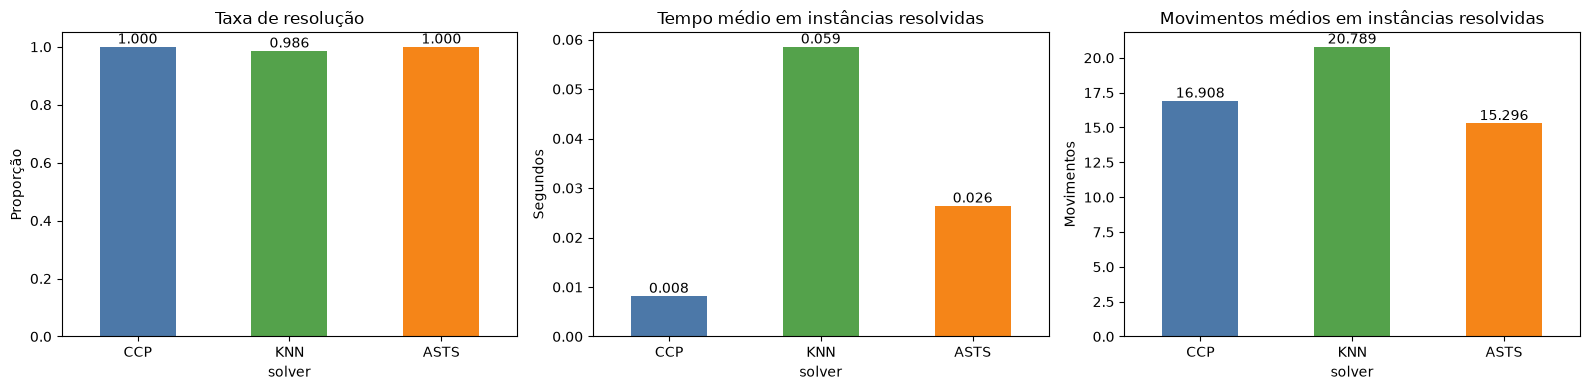

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

solver_colors = [
    '#4c78a8',
    '#54a24b',
    '#f58518',
]

summary_by_solver['taxa_resolucao'].plot(kind='bar', ax=axes[0], color=solver_colors)

axes[0].set_title  ('Taxa de resolução')
axes[0].set_ylabel ('Proporção')
axes[0].set_ylim   (0, 1.05             )
axes[0].tick_params(axis='x', rotation=0)

summary_by_solver['tempo_medio_s'].plot(kind='bar', ax=axes[1], color=solver_colors)

axes[1].set_title  ('Tempo médio em instâncias resolvidas')
axes[1].set_ylabel ('Segundos')
axes[1].tick_params(axis='x', rotation=0)

summary_by_solver['movimentos_medios'].plot(kind='bar', ax=axes[2], color=solver_colors)

axes[2].set_title  ('Movimentos médios em instâncias resolvidas')
axes[2].set_ylabel ('Movimentos')
axes[2].tick_params(axis='x', rotation=0)

for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f')

plt.tight_layout()
plt.show()